# Ataque VQA contra S-AES

**Alumno:** Carlos Yanes Pérez

Implementación del ataque VQE al S-AES basado en el texto de Wang, Z., Zheng, M., Wu, J. et al. *Reducing quantum resources for attacking S-AES on quantum devices.* npj Quantum Inf 11, 157 (2025). (DOI: [10.1038/s41534-025-01106-w](https://www.nature.com/articles/s41534-025-01106-w)). Además, se ha hecho uso de las notas suplementarias de dicha publicación.

> El código ha sido refactorizado usando Claude Sonnet 4.6.

# Instalación e importaciones

In [1]:
%pip install qiskit scipy numpy

import sys
import numpy as np
from scipy.optimize import minimize
from qiskit.quantum_info import Statevector
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import real_amplitudes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.7 MB/s eta 0:00:00


# S-AES

In [2]:
import requests

url = "https://raw.githubusercontent.com/alu0101430720/TFM-CarlosYanesPerez/main/ImplementacionSAES/saes.py"
response = requests.get(url)

if response.status_code == 200:
    with open("saes.py", "wb") as f:
        f.write(response.content)
    print("saes.py descargado.")
else:
    print(f"Fallo al obtener saes.py. Status code: {response.status_code}")

saes.py descargado.


In [3]:
from saes import saes_encrypt, build_ct_table

## Prueba del S-AES
Se hace uso del texto plano y de la clave de Wang et. all. (pág. 4)

In [4]:
P = 0xDF64  # texto plano
K = 0x544A  # clave

C = saes_encrypt(P, K)
print(f"P = 0x{P:04X}  ({P:016b})")
print(f"K = 0x{K:04X}  ({K:016b})")
print(f"C = 0x{C:04X}  ({C:016b})")

P = 0xDF64  (1101111101100100)
K = 0x544A  (0101010001001010)
C = 0xF4B6  (1111010010110110)


# Hamiltoniano

$$H = \sum_i t_i Z_i + \sum_{i<j} \omega_{ij} Z_i Z_j$$

donde $Z_i$ es el operador de Pauli $Z$ sobre el cúbit $i$, y los coeficientes $t_i$, $\omega_{ij}$ dependen de los bits del criptograma $C$ de modo que el mínimo global de $H$ corresponde a la clave correcta $K_0$.

In [5]:
def precompute_hamiltonian(ciphertext, ct_table):
    """
    Precomputa h_all[k] = H(saes_encrypt(P, k)) para toda clave k.
    El mínimo global se alcanza cuando k = K_true.
    """
    tb    = np.array([(ciphertext>>(15-i))&1 for i in range(16)], dtype=np.float32)
    t     = np.where(tb==1, 1.0, -1.0)
    omega = np.triu(np.where(tb[:,None]!=tb[None,:], 1.0, -1.0).astype(np.float32), 1)
    ct    = ct_table.astype(np.int32)
    bits  = ((ct[:,None] >> (15-np.arange(16))) & 1).astype(np.float32)
    z     = np.where(bits==1, 1.0, -1.0)
    return z @ t + np.einsum('ki,kj,ij->k', z, z, omega)

# Ansatz y función de coste

Ansatz simple: capa de puertas $R_y(\theta_i)$ sobre 16 cúbits independientes (16 parámetros).
Consistente con el vector de inicialización del Supplementary Note III de Wang et al.

Para $\theta_i \in \{0, \pi\}$ prepara exactamente cualquier estado base computacional,
garantizando que el espacio de soluciones es completo.

In [6]:
def build_ansatz(n_qubits=16):
    """
    Ansatz para el VQAA.

    """
    qc     = real_amplitudes(n_qubits, reps=1)
    params = list(qc.parameters)
    return qc, params


def evaluate_cost(theta_vals, qc, params, h_all):
    """C(θ)"""
    bound = qc.assign_parameters(dict(zip(params, theta_vals)))
    probs = np.abs(Statevector(bound).data)**2
    return float(probs @ h_all)


def get_fidelity(theta_vals, qc, params, key_true):
    """Fidelidad"""
    bound = qc.assign_parameters(dict(zip(params, theta_vals)))
    probs = np.abs(Statevector(bound).data)**2
    return float(probs[key_true])

# Inicialización

Los parámetros se inicializan perturbando los ángulos exactos de la clave objetivo:
$$\theta_i = \pi \cdot (K_0)_i + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$$
donde $(K_0)_i$ es el bit $i$ de la clave en convenio little-endian de Qiskit.

Con $\sigma = 0.5$ la fidelidad inicial es aproximadamente $0.32$.

In [7]:
def init_near_target(key_true, sigma=0.5):
    """
    Inicialización cercana al estado objetivo.
    """
    key_bits   = [(key_true >> i) & 1 for i in range(16)]
    theta_base = np.array([np.pi if b else 0.0 for b in key_bits])
    perturb    = theta_base + np.random.normal(0, sigma, 16)

    return np.concatenate([np.zeros(16), perturb])

# Bucle variacional

In [8]:
def run_vqaa(plaintext, ciphertext, key_true=None,
             use_near_init=True,
             xerr=-80.0, max_iter=500, n_restarts=5):
    """
    Bucle variacional con criterio de parada y reinicios.

    Parámetros
    ----------
    use_near_init       : True  → inicialización cercana al objetivo
                          False → inicialización aleatoria en [-π, π]
    xerr                : Umbral de parada. Se detiene cuando C(θ) < xerr.

    Nota: con inicialización aleatoria la convergencia no está garantizada
    debido al paisaje accidentado de la función de coste.
    """
    ct_table = build_ct_table(plaintext)
    if key_true is not None:
        assert ct_table[key_true] == ciphertext, "Par (P, C, K) inconsistente"

    h_all      = precompute_hamiltonian(ciphertext, ct_table)
    qc, params = build_ansatz(n_qubits=16)
    n_params   = len(params)

    ansatz_label = "RealAmplitudes reps=1 (Ry+CNOT+Ry, 32 params)"
    init_label   = "cercana al objetivo" if use_near_init else "aleatoria"

    print("=" * 64)
    print("VQAA para S-AES")
    print("=" * 64)
    print(f"Ansatz      : {ansatz_label}")
    print(f"Init        : {init_label}")
    print(f"Umbral xerr : {xerr}")
    print(f"Texto plano : 0x{plaintext:04X}  ({plaintext:016b})")
    print(f"Criptograma : 0x{ciphertext:04X}  ({ciphertext:016b})")
    if key_true is not None:
        print(f"Clave real  : 0x{key_true:04X}  ({key_true:016b})")
    print()

    best_result = None
    best_cost   = np.inf

    for restart in range(n_restarts):
        if use_near_init:
            theta0 = init_near_target(key_true, sigma=0.5)
        else:
            theta0 = np.random.uniform(-np.pi, np.pi, n_params)

        fid0  = get_fidelity(theta0, qc, params, key_true) if key_true else 0
        cost0 = evaluate_cost(theta0, qc, params, h_all)

        result = minimize(
            evaluate_cost, theta0,
            args=(qc, params, h_all),
            method='Nelder-Mead',
            options={'maxiter': max_iter, 'xatol': 1e-5,
                     'fatol': 1e-5, 'disp': False}
        )

        fid1 = get_fidelity(result.x, qc, params, key_true) if key_true else 0
        print(f"  Reinicio {restart+1}/{n_restarts} | "
              f"C: {cost0:7.2f} -> {result.fun:7.2f} | "
              f"Fidelidad: {fid0:.3f} -> {fid1:.3f} | "
              f"Iter: {result.nit:4d}")

        if result.fun < best_cost:
            best_cost, best_result = result.fun, result

        if result.fun < xerr:
            print(f"  Umbral xerr={xerr} alcanzado. Deteniendo.\n")
            break

    # ── Resultado ─────────────────────────────────────────────────────────────
    print(f"\nMejor coste: {best_cost:.4f}")
    bound  = qc.assign_parameters(dict(zip(params, best_result.x)))
    probs  = np.abs(Statevector(bound).data)**2
    top    = np.argsort(probs)[::-1][:10]

    print(f"\nTop-10 claves más probables:")
    print(f"  {'#':>3}  {'Clave':>8}  {'Prob':>9}  "
          f"{'S-AES(P,K)':>12}  {'H(K)':>7}  Resultado")
    print("  " + "-" * 62)
    for rank, idx in enumerate(top, 1):
        ct   = int(ct_table[idx])
        flag = ("CLAVE" if idx == key_true else
                "CT"    if ct == ciphertext else "")
        print(f"  {rank:>3}  0x{idx:04X}    {probs[idx]:9.6f}  "
              f"0x{ct:04X}        {h_all[idx]:7.1f}  {flag}")

    if key_true is not None:
        fid_best  = get_fidelity(best_result.x, qc, params, key_true)
        rank_true = np.argsort(probs)[::-1].tolist().index(key_true) + 1
        print(f"\nClave real (0x{key_true:04X}):")
        print(f"  Posición  : #{rank_true}")
        print(f"  Prob      : {probs[key_true]:.6f}")
        print(f"  Fidelidad : {fid_best:.4f}")

    return best_result, probs

# Ejecución

Modifica `USE_RANDOM` para explorar los dos escenarios:

| `USE_RANDOM` | Experimento |
|:---:|---|
| `False` | Inicialización cercana al objetivo - demuestra la viabilidad del método |
| `True`  | Inicialización aleatoria - ilustra la limitación sin conocimiento previo |

In [9]:
np.random.seed(0)

# ── Configuración ──────────────────────────────────────────────────────────────
USE_RANDOM          = False  # True → inicialización aleatoria en [-π, π]
# ──────────────────────────────────────────────────────────────────────────────

PLAINTEXT  = 0xDF64
CIPHERTEXT = 0xF4B6
KEY_TRUE   = 0x544A

assert saes_encrypt(PLAINTEXT, KEY_TRUE) == CIPHERTEXT, "Error en S-AES"
print("S-AES verificado correctamente.\n")

run_vqaa(
    plaintext           = PLAINTEXT,
    ciphertext          = CIPHERTEXT,
    key_true            = KEY_TRUE,
    use_near_init       = not USE_RANDOM,
    xerr                = -80.0,
    max_iter            = 500,
    n_restarts          = 5,
)

S-AES verificado correctamente.

VQAA para S-AES
Ansatz      : RealAmplitudes reps=1 (Ry+CNOT+Ry, 32 params)
Init        : cercana al objetivo
Umbral xerr : -80.0
Texto plano : 0xDF64  (1101111101100100)
Criptograma : 0xF4B6  (1111010010110110)
Clave real  : 0x544A  (0101010001001010)

  Reinicio 1/5 | C:  -39.99 ->  -92.46 | Fidelidad: 0.316 -> 0.880 | Iter:  500
  Umbral xerr=-80.0 alcanzado. Deteniendo.


Mejor coste: -92.4622

Top-10 claves más probables:
    #     Clave       Prob    S-AES(P,K)     H(K)  Resultado
  --------------------------------------------------------------
    1  0x544A     0.880185  0xF4B6         -104.0  CLAVE
    2  0x545A     0.032951  0x3B68          -32.0  
    3  0x546A     0.027876  0xCA2F            4.0  
    4  0x5C4A     0.009750  0x7C69            4.0  
    5  0x564A     0.006001  0x070F          -16.0  
    6  0x504A     0.005990  0x10EA            8.0  
    7  0x544E     0.005120  0x91BC            4.0  
    8  0xD44A     0.004982  0xC293       

(       message: Maximum number of iterations has been exceeded.
        success: False
         status: 2
            fun: -92.46215594515353
              x: [ 3.462e-03  5.841e-04 ...  3.248e+00  1.420e-01]
            nit: 500
           nfev: 568
  final_simplex: (array([[ 3.462e-03,  5.841e-04, ...,  3.248e+00,
                          1.420e-01],
                        [ 3.065e-03,  8.937e-04, ...,  3.251e+00,
                          1.427e-01],
                        ...,
                        [ 2.290e-03,  4.751e-04, ...,  3.280e+00,
                          1.482e-01],
                        [ 2.204e-03,  4.886e-04, ...,  3.307e+00,
                          1.490e-01]]), array([-9.246e+01, -8.975e+01, ..., -8.296e+01, -8.288e+01])),
 array([1.45546991e-15, 1.80706761e-19, 2.95548331e-13, ...,
        5.92919823e-26, 1.43277891e-19, 1.85361036e-22]))

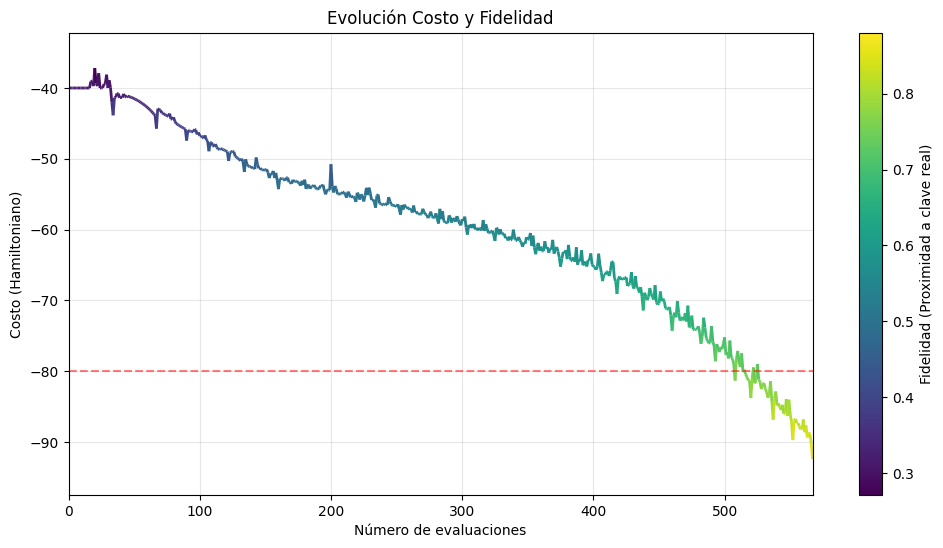

Fidelidad Final: 0.8802


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

def run_vqaa_with_gradient_logging(plaintext, ciphertext, key_true=None, use_near_init=True, xerr=-80.0, max_iter=500):
    np.random.seed(0)
    ct_table = build_ct_table(plaintext)
    h_all = precompute_hamiltonian(ciphertext, ct_table)
    qc, params = build_ansatz(n_qubits=16)

    if use_near_init:
        theta0 = init_near_target(key_true, sigma=0.5)
    else:
        theta0 = np.random.uniform(-np.pi, np.pi, len(params))

    all_evals = []
    fidelities = []

    def cost_wrapper(theta):
        val = evaluate_cost(theta, qc, params, h_all)
        fid = get_fidelity(theta, qc, params, key_true)
        all_evals.append(val)
        fidelities.append(fid)
        return val

    res = minimize(cost_wrapper, theta0, method='Nelder-Mead', options={'maxiter': max_iter})

    # Preparación del gráfico con gradiente
    x = np.arange(len(all_evals))
    y = np.array(all_evals)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Crear el gradiente basado en la fidelidad
    norm = plt.Normalize(min(fidelities), max(fidelities))
    lc = LineCollection(segments, cmap='viridis', norm=norm)
    lc.set_array(np.array(fidelities))
    lc.set_linewidth(2)
    line = ax1.add_collection(lc)

    ax1.set_xlim(x.min(), x.max())
    ax1.set_ylim(y.min() - 5, y.max() + 5)
    ax1.set_xlabel('Número de evaluaciones')
    ax1.set_ylabel('Costo (Hamiltoniano)', color='black')
    ax1.axhline(y=xerr, color='red', linestyle='--', alpha=0.5, label=f'Umbral xerr ({xerr})')

    cbar = fig.colorbar(line, ax=ax1)
    cbar.set_label('Fidelidad (Proximidad a clave real)')

    plt.title("Evolución Costo y Fidelidad")
    ax1.grid(True, alpha=0.3)
    plt.show()

    print(f"Fidelidad Final: {fidelities[-1]:.4f}")
    return res

result = run_vqaa_with_gradient_logging(PLAINTEXT, CIPHERTEXT, KEY_TRUE, use_near_init=not USE_RANDOM)